In [1]:
!pip install -q sentencepiece accelerate pillow

In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional, Tuple
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


---
# 1) Advanced RoPE Scaling

RoPE is trained with a fixed context window (e.g., 2048 tokens). When the
model encounters sequences **longer** than this window at inference, the
high-frequency components of RoPE produce unseen angle values, leading to
catastrophic attention score degradation.

Three progressive solutions have been developed:

| Method | Key Idea | Used By |
|---|---|---|
| Position Interpolation (PI) | Linearly compress positions | Meta (Code Llama) |
| NTK-Aware Interpolation | Scale the **base frequency** θ | Qwen-1 |
| Dynamic NTK | Scale θ dynamically at inference | Qwen-1.5, 2 |
| YaRN | Per-dimension interpolation + temp | Qwen-2, many others |

In [3]:
def rope_standard(
    head_dim: int,
    max_len: int,
    base: float = 10000.0,
    device: str = "cpu",
) -> torch.Tensor:
    """Standard RoPE frequency computation.

    Returns:
        freqs: (max_len, head_dim // 2) — real-valued angles (m * theta_i)
    """
    # Compute base frequencies: theta_i = base^{-2i / head_dim}
    # (head_dim // 2,)
    dim_indices = torch.arange(0, head_dim, 2, device=device).float()
    theta = 1.0 / (base ** (dim_indices / head_dim))

    # Position indices
    # (max_len,)
    positions = torch.arange(max_len, device=device).float()

    # Outer product: (max_len,) × (head_dim // 2,) → (max_len, head_dim // 2)
    freqs = torch.outer(positions, theta)
    return freqs

## 1.1 Position Interpolation (PI)

The simplest context extension: linearly **compress** all positions so
that position `max_len_extended` maps to where `max_len_original` used to be.

$$m' = m \cdot \frac{L_{\text{original}}}{L_{\text{extended}}}$$

**Problem:** This uniformly scales ALL frequency dimensions, but high-frequency
components don't need scaling (they cycle quickly and stay within training
distribution). Only the low-frequency components extrapolate.

Reference: Extending Context Window of Large Language Models via
           Position Interpolation (arXiv 2306.15595)

In [4]:
def rope_position_interpolation(
    head_dim: int,
    max_len: int,
    original_max_len: int,
    base: float = 10000.0,
    device: str = "cpu",
) -> torch.Tensor:
    """Position Interpolation (PI): linearly compress positions.

    Returns:
        freqs: (max_len, head_dim // 2)
    """
    # Compute compression ratio
    scale = original_max_len / max_len

    # Same base frequencies as standard RoPE
    # (head_dim // 2,)
    dim_indices = torch.arange(0, head_dim, 2, device=device).float()
    theta = 1.0 / (base ** (dim_indices / head_dim))

    # Compressed position indices: positions are scaled down
    # (max_len,)
    positions = torch.arange(max_len, device=device).float() * scale

    # (max_len, head_dim // 2)
    freqs = torch.outer(positions, theta)
    return freqs

## 1.2 NTK-Aware Interpolation

Instead of compressing positions (which hurts high-frequency dims),
NTK-Aware scaling increases the **base frequency** $\theta_{\text{base}}$.
This spreads out the frequency spectrum non-uniformly:
- **Low-frequency** dims (which extrapolate) are interpolated more.
- **High-frequency** dims (which stay in distribution) are barely affected.

$$\theta'_{\text{base}} = \theta_{\text{base}} \cdot \alpha^{d/(d-2)}$$

where $\alpha = L_{\text{extended}} / L_{\text{original}}$ is the scaling factor.

This is the method used in **Qwen-1**.

Reference: Reddit / bloc97 "NTK-Aware Scaled RoPE" (2023)

In [5]:
def rope_ntk_aware(
    head_dim: int,
    max_len: int,
    original_max_len: int,
    base: float = 10000.0,
    device: str = "cpu",
) -> torch.Tensor:
    """NTK-Aware RoPE scaling: increase base frequency.

    The key insight from Neural Tangent Kernel theory:
    scaling the base preserves high-frequency information while
    interpolating low-frequency components.

    Returns:
        freqs: (max_len, head_dim // 2)
    """
    # Scaling factor alpha
    alpha = max_len / original_max_len

    # Rescale base frequency using NTK formula
    # Higher base → lower frequencies → longer effective wavelengths
    scaled_base = base * (alpha ** (head_dim / (head_dim - 2)))

    # Compute frequencies with rescaled base
    # (head_dim // 2,)
    dim_indices = torch.arange(0, head_dim, 2, device=device).float()
    theta = 1.0 / (scaled_base ** (dim_indices / head_dim))

    # Standard position indices (NOT compressed)
    # (max_len,)
    positions = torch.arange(max_len, device=device).float()

    # (max_len, head_dim // 2)
    freqs = torch.outer(positions, theta)
    return freqs

## 1.3 Dynamic NTK

Dynamic NTK applies NTK-Aware scaling **only when the sequence length
exceeds the training window**. When the sequence is within the original
window, standard RoPE is used. This is a simple but effective inference-time
trick used in Qwen-1.5 and Qwen-2.

```
if current_len <= original_max_len:
    use standard RoPE
else:
    alpha = current_len / original_max_len
    use NTK-Aware RoPE with alpha
```

In [6]:
def rope_dynamic_ntk(
    head_dim: int,
    current_len: int,
    original_max_len: int,
    base: float = 10000.0,
    device: str = "cpu",
) -> torch.Tensor:
    """Dynamic NTK scaling: adapt base frequency at inference time.

    If current_len <= original_max_len, returns standard RoPE.
    Otherwise, applies NTK-aware scaling with dynamic alpha.

    Returns:
        freqs: (current_len, head_dim // 2)
    """
    if current_len <= original_max_len:
        # Within training window: use standard RoPE
        return rope_standard(head_dim, current_len, base, device)
    else:
        # Beyond training window: apply NTK-aware scaling
        return rope_ntk_aware(
            head_dim, current_len, original_max_len, base, device
        )

## 1.4 YaRN — Yet another RoPE extensioN

YaRN combines the best of PI and NTK-Aware by applying
**per-dimension** interpolation ratios. Dimensions are split into
three groups based on their wavelength relative to the context window:

| Wavelength | Group | Strategy |
|---|---|---|
| λ > L × β_high | Low-freq | **Interpolate** (like PI) |
| λ < L × β_low | High-freq | **No change** (already in distribution) |
| In between | Medium-freq | **Smooth ramp** between the two |

Additionally, a **temperature scaling** factor $\sqrt{t}$ is applied to
attention logits to compensate for the distribution shift in attention
entropy caused by interpolation.

$$\theta'_i = \theta_i / \big( (1 - \gamma_i) \cdot s + \gamma_i \big)$$

where $s$ is the scale factor and $\gamma_i \in [0, 1]$ is the ramp function.

In [7]:
def rope_yarn(
    head_dim: int,
    max_len: int,
    original_max_len: int,
    base: float = 10000.0,
    beta_low: float = 1.0,
    beta_high: float = 32.0,
    device: str = "cpu",
) -> Tuple[torch.Tensor, float]:
    """YaRN: per-dimension RoPE scaling with temperature.

    Args:
        head_dim:         dimension of each attention head
        max_len:          target extended context length
        original_max_len: training context length
        base:             RoPE base frequency (default 10000)
        beta_low:         lower boundary for frequency ramp
        beta_high:        upper boundary for frequency ramp
    Returns:
        freqs:       (max_len, head_dim // 2) — angle values
        temperature: scalar — sqrt(t) for attention logit scaling
    """
    # Context extension ratio
    scale = max_len / original_max_len

    # Compute standard base frequencies
    # (head_dim // 2,)
    dim_indices = torch.arange(0, head_dim, 2, device=device).float()
    theta = 1.0 / (base ** (dim_indices / head_dim))

    # Compute wavelength for each dimension pair
    # wavelength_i = 2π / theta_i
    # (head_dim // 2,)
    wavelengths = 2 * math.pi / theta

    # Classify dimensions: compute ramp function gamma_i ∈ [0, 1]
    # Low-freq dims (long wavelength) → gamma ≈ 0 → full interpolation
    # High-freq dims (short wavelength) → gamma ≈ 1 → no change
    low_threshold = original_max_len * beta_low
    high_threshold = original_max_len * beta_high

    # Linear ramp between thresholds
    # (head_dim // 2,)
    gamma = torch.clamp(
        (wavelengths - low_threshold) / (high_threshold - low_threshold),
        0.0,
        1.0,
    )

    # Per-dimension effective scale:
    # gamma=0 → full scale (interpolation), gamma=1 → scale=1 (no change)
    # effective_scale = (1 - gamma) * scale + gamma * 1.0
    # (head_dim // 2,)
    effective_scale = (1.0 - gamma) * scale + gamma

    # Apply per-dimension scaling to frequencies
    # theta'_i = theta_i / effective_scale_i
    # Equivalently: position is compressed by effective_scale for that dim
    # (head_dim // 2,)
    theta_scaled = theta / effective_scale

    # Position indices (uncompressed)
    # (max_len,)
    positions = torch.arange(max_len, device=device).float()

    # Compute angle matrix
    # (max_len, head_dim // 2)
    freqs = torch.outer(positions, theta_scaled)

    # Temperature scaling: compensates for entropy shift in attention
    # t = 0.1 * ln(s) + 1  (empirical formula from YaRN paper)
    temperature = 0.1 * math.log(scale) + 1.0

    return freqs, temperature

YaRN temperature scaling factor: 1.1386


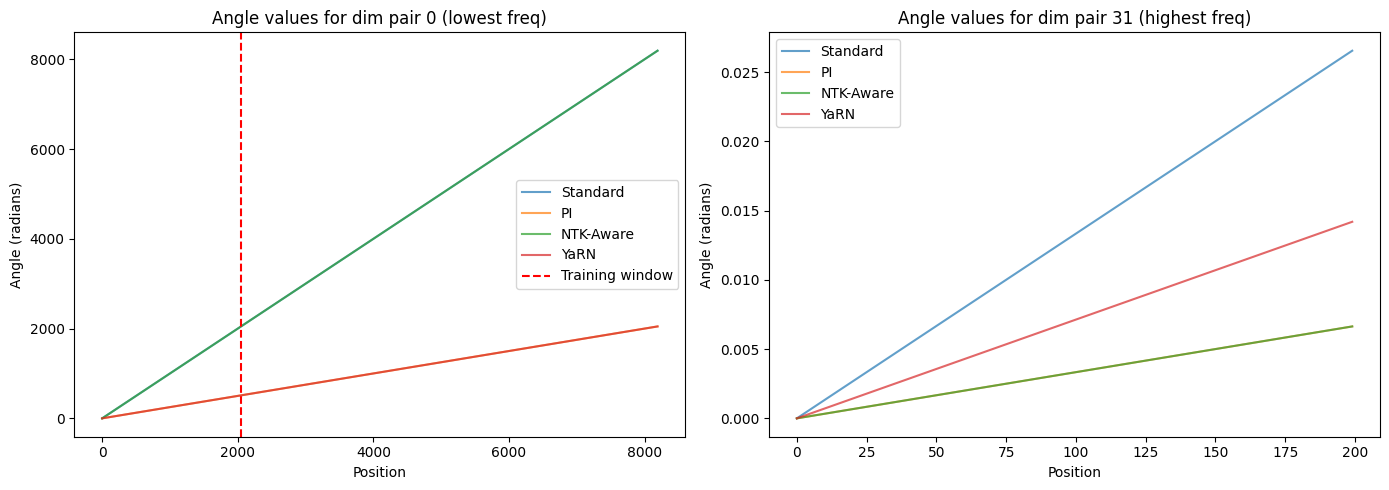

In [8]:
# ── Compare all RoPE scaling methods visually ─────────────────────
head_dim = 64
original_max_len = 2048
extended_max_len = 8192

# Compute frequencies for each method
freqs_std = rope_standard(head_dim, extended_max_len)
freqs_pi = rope_position_interpolation(head_dim, extended_max_len, original_max_len)
freqs_ntk = rope_ntk_aware(head_dim, extended_max_len, original_max_len)
freqs_yarn, yarn_temp = rope_yarn(head_dim, extended_max_len, original_max_len)

print(f"YaRN temperature scaling factor: {yarn_temp:.4f}")

# Plot the frequencies for dimension pair 0 (lowest frequency)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dim_idx = 0
positions = np.arange(extended_max_len)

ax = axes[0]
ax.set_title(f"Angle values for dim pair {dim_idx} (lowest freq)")
ax.plot(positions, freqs_std[:, dim_idx].numpy(), label="Standard", alpha=0.7)
ax.plot(positions, freqs_pi[:, dim_idx].numpy(), label="PI", alpha=0.7)
ax.plot(positions, freqs_ntk[:, dim_idx].numpy(), label="NTK-Aware", alpha=0.7)
ax.plot(positions, freqs_yarn[:, dim_idx].numpy(), label="YaRN", alpha=0.7)
ax.axvline(x=original_max_len, color="red", linestyle="--", label="Training window")
ax.set_xlabel("Position")
ax.set_ylabel("Angle (radians)")
ax.legend()

dim_idx = head_dim // 2 - 1
ax = axes[1]
ax.set_title(f"Angle values for dim pair {dim_idx} (highest freq)")
ax.plot(positions[:200], freqs_std[:200, dim_idx].numpy(), label="Standard", alpha=0.7)
ax.plot(positions[:200], freqs_pi[:200, dim_idx].numpy(), label="PI", alpha=0.7)
ax.plot(positions[:200], freqs_ntk[:200, dim_idx].numpy(), label="NTK-Aware", alpha=0.7)
ax.plot(positions[:200], freqs_yarn[:200, dim_idx].numpy(), label="YaRN", alpha=0.7)
ax.set_xlabel("Position")
ax.set_ylabel("Angle (radians)")
ax.legend()

plt.tight_layout()
plt.show()

---
# 2) Qwen2 Architecture Details

While Qwen2 shares the LLaMA-style decoder-only design (RMSNorm, SwiGLU,
GQA), it introduces several refinements:

| Feature | LLaMA 2 | Qwen2 |
|---|---|---|
| QKV bias | No bias | **Bias on Q and K** (not V) |
| Attention type | GQA | GQA + **Sliding Window Attention** on alternating layers |
| RoPE scaling | Standard | **YaRN** (Dynamic NTK in Qwen-1.5) |
| Vocabulary | 32K (SentencePiece) | **152K** (tiktoken-based, incl. multilingual) |

### Why QKV Bias?

Adding bias to Q and K allows the model to learn position-independent
offsets in the attention space, complementing the position-dependent
RoPE rotation. Empirically this improves extrapolation.

### Sliding Window Attention (SWA)

Full causal attention has O(n²) complexity. SWA restricts each token
to attend only to the preceding W tokens (the window). When alternated
with full attention layers, the effective receptive field grows
layer-by-layer, enabling long-range reasoning while saving compute.

```
Full attention mask:            SWA mask (window=4):
 1 0 0 0 0                       1 0 0 0 0
 1 1 0 0 0                       1 1 0 0 0
 1 1 1 0 0                       1 1 1 0 0
 1 1 1 1 0                       1 1 1 1 0
 1 1 1 1 1                       0 1 1 1 1  ← only last W tokens
```

In [10]:
def make_causal_mask(seq_len: int, device: str = "cpu") -> torch.Tensor:
    """Standard lower-triangular causal mask.

    Returns:
        mask: (1, 1, seq_len, seq_len) — True where attention is allowed
    """
    mask = torch.tril(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool))
    return mask.unsqueeze(0).unsqueeze(0)

def make_sliding_window_mask(
    seq_len: int, window_size: int, device: str = "cpu"
) -> torch.Tensor:
    """Causal sliding window attention mask.

    Each token attends to at most the preceding `window_size` tokens
    (including itself).

    Returns:
        mask: (1, 1, seq_len, seq_len) — True where attention is allowed
    """
    # Start with standard causal mask
    # (seq_len, seq_len)
    mask = torch.tril(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool))

    # Zero out positions further than window_size below the diagonal
    # (seq_len, seq_len)
    window_mask = torch.triu(
        torch.ones(seq_len, seq_len, device=device, dtype=torch.bool),
        diagonal=-(window_size - 1),
    )

    # Combine: causal AND within window
    mask = mask & window_mask
    return mask.unsqueeze(0).unsqueeze(0)

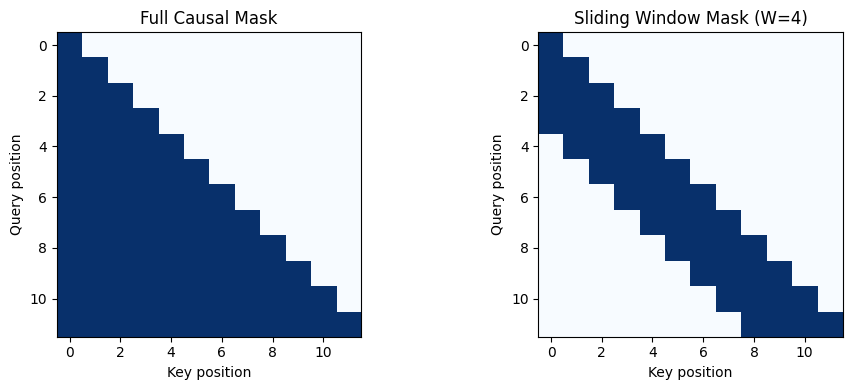

In [11]:
# ── Visualise the two mask types ──────────────────────────────────
seq_len_vis = 12
window_size = 4

causal = make_causal_mask(seq_len_vis).squeeze().float()
swa = make_sliding_window_mask(seq_len_vis, window_size).squeeze().float()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(causal.numpy(), cmap="Blues")
axes[0].set_title("Full Causal Mask")
axes[1].imshow(swa.numpy(), cmap="Blues")
axes[1].set_title(f"Sliding Window Mask (W={window_size})")
for ax in axes:
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
plt.tight_layout()
plt.show()

In [12]:
class Qwen2Attention(nn.Module):
    """Qwen2 Grouped-Query Attention with optional Sliding Window.

    Key differences from LLaMA GQA:
      * Bias is added to Q and K projections (not V).
      * Supports sliding window attention via mask.
      * RoPE frequencies are provided externally (to support YaRN / Dynamic NTK).

    Reference: Qwen2 Technical Report (arXiv 2407.10671)
    """

    def __init__(
        self,
        model_dim: int,
        num_heads: int,
        num_kv_heads: int,
        head_dim: int,
    ):
        super().__init__()
        self.num_heads = num_heads
        self.num_kv_heads = num_kv_heads
        self.head_dim = head_dim
        self.num_groups = num_heads // num_kv_heads

        # Query projection WITH bias
        # (batch_num, seq_len, model_dim) → (batch_num, seq_len, num_heads * head_dim)
        self.wq = nn.Linear(model_dim, num_heads * head_dim, bias=True)

        # Key projection WITH bias
        # (batch_num, seq_len, model_dim) → (batch_num, seq_len, num_kv_heads * head_dim)
        self.wk = nn.Linear(model_dim, num_kv_heads * head_dim, bias=True)

        # Value projection WITHOUT bias (standard)
        # (batch_num, seq_len, model_dim) → (batch_num, seq_len, num_kv_heads * head_dim)
        self.wv = nn.Linear(model_dim, num_kv_heads * head_dim, bias=False)

        # Output projection
        # (batch_num, seq_len, num_heads * head_dim) → (batch_num, seq_len, model_dim)
        self.wo = nn.Linear(num_heads * head_dim, model_dim, bias=False)

    def _apply_rope(self, x: torch.Tensor, freqs: torch.Tensor) -> torch.Tensor:
        """Apply RoPE to a tensor of shape (batch, seq, heads, head_dim)."""

        # Reshape last dim into pairs for complex multiplication
        x_pairs = x.float().reshape(*x.shape[:-1], -1, 2)
        x_complex = torch.view_as_complex(x_pairs)

        # freqs: (seq_len, head_dim // 2) → broadcast
        f = torch.polar(torch.ones_like(freqs), freqs)
        f = f.unsqueeze(0).unsqueeze(2)  # (1, seq_len, 1, head_dim // 2)

        x_rotated = x_complex * f
        return torch.view_as_real(x_rotated).reshape(x.shape).type_as(x)

    def _repeat_kv(self, x: torch.Tensor) -> torch.Tensor:
        """Repeat KV heads to match number of query heads.
        """
        if self.num_groups == 1:
            return x

        # (batch_num, seq_len, num_kv_heads, head_dim)
        batch_num, seq_len, num_kv_heads, head_dim = x.shape

        # (batch_num, seq_len, num_heads, head_dim)
        return (
            x[:, :, :, None, :]
            .expand(batch_num, seq_len, num_kv_heads, self.num_groups, head_dim)
            .reshape(batch_num, seq_len, self.num_heads, head_dim)
        )

    def forward(
        self,
        x: torch.Tensor,
        rope_freqs: torch.Tensor,
        mask: torch.Tensor,
        attn_temperature: float = 1.0,
    ) -> torch.Tensor:
        """Forward pass.

        Args:
            x:                (batch_num, seq_len, model_dim)
            rope_freqs:       (seq_len, head_dim // 2)
            mask:             (1, 1, seq_len, seq_len) bool
            attn_temperature: scalar (from YaRN)
        Returns:
            output: (batch_num, seq_len, model_dim)
        """
        batch_num, seq_len, _ = x.shape

        # Project Q, K, V and reshape into heads
        # Q: (batch_num, seq_len, num_heads, head_dim)
        q = self.wq(x).view(batch_num, seq_len, self.num_heads, self.head_dim)
        # K: (batch_num, seq_len, num_kv_heads, head_dim)
        k = self.wk(x).view(batch_num, seq_len, self.num_kv_heads, self.head_dim)
        # V: (batch_num, seq_len, num_kv_heads, head_dim)
        v = self.wv(x).view(batch_num, seq_len, self.num_kv_heads, self.head_dim)

        # Apply RoPE to Q and K
        q = self._apply_rope(q, rope_freqs)
        k = self._apply_rope(k, rope_freqs)

        # Expand KV heads to match Q heads (GQA)
        k = self._repeat_kv(k)
        v = self._repeat_kv(v)

        # Transpose to (batch_num, num_heads, seq_len, head_dim)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # Scaled dot-product attention with optional YaRN temperature
        # (batch_num, num_heads, seq_len, seq_len)
        scores = torch.matmul(q, k.transpose(-2, -1)) / (
            math.sqrt(self.head_dim) * attn_temperature
        )

        # Apply mask
        scores = scores.masked_fill(~mask, float("-inf"))

        attn_weights = F.softmax(scores, dim=-1)

        # (batch_num, num_heads, seq_len, head_dim)
        context = torch.matmul(attn_weights, v)

        # Merge heads → (batch_num, seq_len, num_heads * head_dim)
        context = context.transpose(1, 2).contiguous().view(
            batch_num, seq_len, self.num_heads * self.head_dim
        )

        # Output projection → (batch_num, seq_len, model_dim)
        return self.wo(context)

In [13]:
class Qwen2Block(nn.Module):
    """Single Qwen2 decoder block.

    Architecture: pre-norm (RMSNorm) → Attention → residual
                  pre-norm (RMSNorm) → SwiGLU FFN → residual

    Supports alternating between full causal and sliding window attention.
    """

    def __init__(
        self,
        model_dim: int,
        num_heads: int,
        num_kv_heads: int,
        head_dim: int,
        ffn_dim: int,
        use_sliding_window: bool = False,
        window_size: int = 4096,
    ):
        super().__init__()
        self.use_sliding_window = use_sliding_window
        self.window_size = window_size

        self.attn_norm = nn.RMSNorm(model_dim)
        self.attn = Qwen2Attention(model_dim, num_heads, num_kv_heads, head_dim)

        self.ffn_norm = nn.RMSNorm(model_dim)

        # SwiGLU FFN (same as LLaMA)
        self.w_gate = nn.Linear(model_dim, ffn_dim, bias=False)
        self.w_up = nn.Linear(model_dim, ffn_dim, bias=False)
        self.w_down = nn.Linear(ffn_dim, model_dim, bias=False)

    def _swiglu_ffn(self, x: torch.Tensor) -> torch.Tensor:
        # (batch_num, seq_len, model_dim) → (batch_num, seq_len, model_dim)
        return self.w_down(F.silu(self.w_gate(x)) * self.w_up(x))

    def forward(
        self,
        x: torch.Tensor,
        rope_freqs: torch.Tensor,
        attn_temperature: float = 1.0,
    ) -> torch.Tensor:
        """Forward pass.

        Args:
            x:                (batch_num, seq_len, model_dim)
            rope_freqs:       (seq_len, head_dim // 2)
            attn_temperature: scalar (from YaRN)
        Returns:
            output: (batch_num, seq_len, model_dim)
        """
        seq_len = x.size(1)

        # Select appropriate mask
        if self.use_sliding_window:
            mask = make_sliding_window_mask(seq_len, self.window_size, x.device)
        else:
            mask = make_causal_mask(seq_len, x.device)

        # Pre-norm → Attention → residual
        h = x + self.attn(self.attn_norm(x), rope_freqs, mask, attn_temperature)

        # Pre-norm → SwiGLU FFN → residual
        out = h + self._swiglu_ffn(self.ffn_norm(h))

        return out

In [14]:
# ── Test Qwen2 block with YaRN ────────────────────────────────────
model_dim = 1024
num_heads = 16
num_kv_heads = 4
head_dim = model_dim // num_heads
ffn_dim = 2816
seq_len = 128

# Full attention block
block_full = Qwen2Block(
    model_dim, num_heads, num_kv_heads, head_dim, ffn_dim,
    use_sliding_window=False
).to(device)

# Sliding window block (alternating pattern in Qwen2)
block_swa = Qwen2Block(
    model_dim, num_heads, num_kv_heads, head_dim, ffn_dim,
    use_sliding_window=True, window_size=32
).to(device)

# Use YaRN frequencies
freqs, temp = rope_yarn(head_dim, seq_len, original_max_len=2048, device=device)

x = torch.randn(2, seq_len, model_dim, device=device)

out_full = block_full(x, freqs, attn_temperature=temp)
out_swa = block_swa(x, freqs, attn_temperature=temp)

print(f"Full attention block output: {out_full.shape}")
print(f"SWA block output:            {out_swa.shape}")

Full attention block output: torch.Size([2, 128, 1024])
SWA block output:            torch.Size([2, 128, 1024])


---
# 3) Qwen2-VL: Vision-Language Architecture

Qwen2-VL extends Qwen2 into a multimodal model that processes both
images and text. The key innovations:

1. **Naive Dynamic Resolution** — images are processed at their native
   resolution (no fixed square crop), preserving aspect ratio.
2. **Multimodal Rotary Position Embedding (M-RoPE)** — extends 1D RoPE
   to handle 2D spatial (image) + 1D temporal (video/text) positions.
3. **Vision Encoder** — a ViT that processes variable-resolution image patches.

### M-RoPE: Multimodal RoPE

Standard RoPE encodes a single position dimension. M-RoPE decomposes the
head dimension into three components:

```
head_dim = d_temporal + d_height + d_width
```

Each component receives its own position ID:
- **Text tokens:** all three components use the same sequential position.
- **Image tokens:** temporal=constant, height and width encode 2D patch grid.
- **Video tokens:** temporal=frame index, height/width encode spatial position.

This lets the model understand spatial relationships within images while
maintaining sequential order for text.

### Sample Input / Output

```
Input:  position_ids (batch_num, 3, seq_len)  — [temporal, height, width]
        head_dim, base
Output: freqs (batch_num, seq_len, head_dim // 2) complex
```

In [15]:
class MultimodalRoPE(nn.Module):
    """Multimodal Rotary Position Embedding (M-RoPE) from Qwen2-VL.

    Decomposes head_dim into three positional components:
      - temporal:  for text sequence order / video frame index
      - height:    for vertical position in image patch grid
      - width:     for horizontal position in image patch grid

    For text tokens, all three components share the same position.
    For image tokens, temporal is fixed while height/width vary.

    Reference: Qwen2-VL (arXiv 2409.12191), Section 3.2
    """

    def __init__(
        self,
        head_dim: int,
        base: float = 10000.0,
    ):
        super().__init__()
        self.head_dim = head_dim

        # Split head_dim into three equal parts for the three position axes
        assert head_dim % 6 == 0, "head_dim must be divisible by 6 for M-RoPE"
        self.dim_per_axis = head_dim // 3
        self.half_dim_per_axis = self.dim_per_axis // 2

        # Precompute base frequencies for each axis (same formula, same dim)
        # (half_dim_per_axis,)
        dim_indices = torch.arange(0, self.dim_per_axis, 2).float()
        self.register_buffer(
            "theta", 1.0 / (base ** (dim_indices / self.dim_per_axis))
        )

    def forward(self, position_ids: torch.Tensor) -> torch.Tensor:
        """Compute M-RoPE frequency tensor.

        Args:
            position_ids: (batch_num, 3, seq_len)
                          [0] = temporal positions
                          [1] = height positions
                          [2] = width positions
        Returns:
            freqs_complex: (batch_num, seq_len, head_dim // 2) complex
        """
        batch_num = position_ids.size(0)

        # Extract position IDs for each axis
        # (batch_num, seq_len)
        pos_t = position_ids[:, 0, :].float()
        pos_h = position_ids[:, 1, :].float()
        pos_w = position_ids[:, 2, :].float()

        # Compute angles for each axis: pos × theta
        # (batch_num, seq_len, 1) × (1, 1, half_dim_per_axis)
        # → (batch_num, seq_len, half_dim_per_axis)
        theta = self.theta.unsqueeze(0).unsqueeze(0)
        angles_t = pos_t.unsqueeze(-1) * theta
        angles_h = pos_h.unsqueeze(-1) * theta
        angles_w = pos_w.unsqueeze(-1) * theta

        # Concatenate along the dimension axis
        # (batch_num, seq_len, 3 * half_dim_per_axis) = (batch_num, seq_len, head_dim // 2)
        angles = torch.cat([angles_t, angles_h, angles_w], dim=-1)

        # Convert to complex exponential
        # (batch_num, seq_len, head_dim // 2) complex
        freqs_complex = torch.polar(torch.ones_like(angles), angles)

        return freqs_complex


def apply_mrope(
    x: torch.Tensor, freqs_complex: torch.Tensor
) -> torch.Tensor:
    """Apply M-RoPE to a tensor.

    Args:
        x:             (batch_num, seq_len, num_heads, head_dim)
        freqs_complex: (batch_num, seq_len, head_dim // 2) complex
    Returns:
        rotated:       (batch_num, seq_len, num_heads, head_dim)
    """
    # Reshape last dim into pairs and convert to complex
    # (batch_num, seq_len, num_heads, head_dim // 2, 2)
    x_pairs = x.float().reshape(*x.shape[:-1], -1, 2)
    # (batch_num, seq_len, num_heads, head_dim // 2) complex
    x_complex = torch.view_as_complex(x_pairs)

    # Broadcast freqs: (batch_num, seq_len, 1, head_dim // 2)
    f = freqs_complex.unsqueeze(2)

    # Rotate via complex multiplication
    x_rotated = x_complex * f

    # Convert back to real
    return torch.view_as_real(x_rotated).reshape(x.shape).type_as(x)

In [16]:
# ── Test M-RoPE with a mixed text + image sequence ────────────────

head_dim_vl = 96  # must be divisible by 6
mrope = MultimodalRoPE(head_dim_vl).to(device)

# Construct position IDs for a sequence:
# [text(3 tokens), image(2×3 grid = 6 patches), text(2 tokens)]
# Total seq_len = 3 + 6 + 2 = 11

batch_num = 1
seq_len_vl = 11

# Text tokens: all three axes use the same sequential position
text_prefix_pos = torch.tensor([[0, 1, 2]], device=device)  # (1, 3)

# Image patches: 2 rows × 3 cols, temporal is fixed at 3
img_temporal = torch.full((1, 6), 3, device=device)  # all same
img_height = torch.tensor([[0, 0, 0, 1, 1, 1]], device=device)  # row index
img_width = torch.tensor([[0, 1, 2, 0, 1, 2]], device=device)   # col index

# Text suffix: sequential positions continue from 4
text_suffix_pos = torch.tensor([[4, 5]], device=device)

# Stack all position IDs: shape (1, 3, 11)
pos_temporal = torch.cat([text_prefix_pos, img_temporal, text_suffix_pos], dim=1)
pos_height = torch.cat([text_prefix_pos, img_height, text_suffix_pos], dim=1)
pos_width = torch.cat([text_prefix_pos, img_width, text_suffix_pos], dim=1)
position_ids = torch.stack([pos_temporal, pos_height, pos_width], dim=1)  # (1, 3, 11)

print("Position IDs (temporal, height, width):")
print(position_ids.squeeze(0))

# Compute M-RoPE frequencies
freqs_complex = mrope(position_ids)
print(f"\nM-RoPE freqs shape: {freqs_complex.shape}")  # (1, 11, 48)

# Apply to a dummy Q tensor
num_heads_vl = 8
q = torch.randn(batch_num, seq_len_vl, num_heads_vl, head_dim_vl, device=device)
q_rotated = apply_mrope(q, freqs_complex)
print(f"Rotated Q shape: {q_rotated.shape}")  # (1, 11, 8, 96)

Position IDs (temporal, height, width):
tensor([[0, 1, 2, 3, 3, 3, 3, 3, 3, 4, 5],
        [0, 1, 2, 0, 0, 0, 1, 1, 1, 4, 5],
        [0, 1, 2, 0, 1, 2, 0, 1, 2, 4, 5]], device='cuda:0')

M-RoPE freqs shape: torch.Size([1, 11, 48])
Rotated Q shape: torch.Size([1, 11, 8, 96])


Qwen2-VL uses a Vision Transformer (ViT) as the vision encoder.
The key innovation is **naive dynamic resolution**: instead of resizing
all images to a fixed size, images are resized to maintain their aspect
ratio while ensuring the total patch count stays within a budget.

```
Image (H, W) → Resize to (H', W') s.t.:
  - H' and W' are multiples of patch_size
  - (H'/patch_size) × (W'/patch_size) ≤ max_patches
  - Aspect ratio H/W ≈ H'/W'
```

The variable number of patches per image is handled by packing them
into a single sequence with appropriate M-RoPE position IDs.

In [17]:
def compute_dynamic_resolution(
    height: int,
    width: int,
    patch_size: int = 14,
    min_patches: int = 4,
    max_patches: int = 256,
) -> Tuple[int, int]:
    """Compute target resolution preserving aspect ratio within patch budget.

    Qwen2-VL resizes images to ensure the patch count stays within
    [min_patches, max_patches] while maintaining aspect ratio.

    Args:
        height, width:  original image dimensions
        patch_size:     ViT patch size
        min_patches:    minimum total patches
        max_patches:    maximum total patches (budget)
    Returns:
        (new_height, new_width): target image dimensions (multiples of patch_size)
    """
    aspect_ratio = width / height

    # Search for the best (num_h, num_w) patch grid that respects constraints
    best_h, best_w = patch_size, patch_size
    best_diff = float("inf")

    for total_patches in range(min_patches, max_patches + 1):
        # Try different height patch counts
        for num_h in range(1, total_patches + 1):
            num_w = total_patches // num_h
            if num_w == 0 or num_h * num_w > max_patches:
                continue

            candidate_ratio = (num_w * patch_size) / (num_h * patch_size)
            diff = abs(candidate_ratio - aspect_ratio)

            if diff < best_diff:
                best_diff = diff
                best_h = num_h * patch_size
                best_w = num_w * patch_size

    return best_h, best_w


# Test dynamic resolution for different image sizes
test_images = [(224, 224), (640, 480), (1920, 1080), (100, 800)]

print("Dynamic resolution mapping (patch_size=14, max_patches=64):")
print(f"{'Original':>16} → {'Resized':>16}  {'Patches':>8}  {'AR error':>10}")
for h, w in test_images:
    new_h, new_w = compute_dynamic_resolution(h, w, patch_size=14, max_patches=64)
    patches = (new_h // 14) * (new_w // 14)
    ar_orig = w / h
    ar_new = new_w / new_h
    print(f"{f'({h}, {w})':>16} → {f'({new_h}, {new_w})':>16}  {patches:>8}  {abs(ar_new - ar_orig):>10.3f}")

Dynamic resolution mapping (patch_size=14, max_patches=64):
        Original →          Resized   Patches    AR error
      (224, 224) →         (28, 28)         4       0.000
      (640, 480) →         (56, 42)        12       0.000
    (1920, 1080) →        (126, 70)        45       0.007
      (100, 800) →        (14, 112)         8       0.000


In [18]:
class Qwen2VisionEncoder(nn.Module):
    """Simplified Qwen2-VL vision encoder.

    Processes image patches through a lightweight ViT and projects
    the output to the language model's model_dim.

    This implementation demonstrates the key ideas:
    - Patch embedding from variable-resolution images
    - 2D position encoding via M-RoPE-compatible position IDs
    - Projection to LLM hidden dimension

    For simplicity, we use a single Transformer layer; the actual model
    uses a full ViT stack.
    """

    def __init__(
        self,
        patch_size: int = 14,
        in_channels: int = 3,
        vision_dim: int = 1024,
        llm_dim: int = 1024,
        num_heads: int = 16,
    ):
        super().__init__()
        self.patch_size = patch_size

        # Patch embedding: Conv2D with kernel=stride=patch_size
        # (batch_num, in_channels, H, W) → (batch_num, vision_dim, H/P, W/P)
        self.patch_embed = nn.Conv2d(
            in_channels, vision_dim, kernel_size=patch_size, stride=patch_size
        )

        # Single Transformer encoder layer (simplified; real model has more)
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=vision_dim,
            nhead=num_heads,
            dim_feedforward=vision_dim * 4,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        # Project vision features to LLM dimension
        # (batch_num, num_patches, vision_dim) → (batch_num, num_patches, llm_dim)
        self.proj = nn.Linear(vision_dim, llm_dim, bias=False)

    def forward(
        self, pixel_values: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """Encode image into patch features + 2D position IDs.

        Args:
            pixel_values: (batch_num, in_channels, H, W)
        Returns:
            features:    (batch_num, num_patches, llm_dim)
            grid_shape:  (num_h, num_w) — patch grid dimensions
        """
        batch_num = pixel_values.size(0)

        # Extract patch embeddings
        # (batch_num, 3, H, W) → (batch_num, vision_dim, H/P, W/P)
        patches = self.patch_embed(pixel_values)
        num_h, num_w = patches.shape[2], patches.shape[3]

        # Flatten spatial dims to sequence
        # (batch_num, vision_dim, H/P, W/P) → (batch_num, num_patches, vision_dim)
        patches = patches.flatten(2).transpose(1, 2)

        # Pass through vision Transformer
        # (batch_num, num_patches, vision_dim)
        encoded = self.encoder_layer(patches)

        # Project to LLM dimension
        # (batch_num, num_patches, llm_dim)
        features = self.proj(encoded)

        return features, (num_h, num_w)


def build_image_position_ids(
    grid_h: int,
    grid_w: int,
    temporal_offset: int,
    device: str = "cpu",
) -> torch.Tensor:
    """Build M-RoPE position IDs for image patches.

    Args:
        grid_h, grid_w:   patch grid dimensions
        temporal_offset:  temporal position for these image tokens
    Returns:
        position_ids: (1, 3, num_patches) — [temporal, height, width]
    """
    num_patches = grid_h * grid_w

    # Temporal: constant for all patches in the same image
    # (num_patches,)
    pos_t = torch.full((num_patches,), temporal_offset, device=device)

    # Height: row index for each patch (repeated for each column)
    # (num_patches,)
    pos_h = torch.arange(grid_h, device=device).repeat_interleave(grid_w)

    # Width: column index for each patch (tiled for each row)
    # (num_patches,)
    pos_w = torch.arange(grid_w, device=device).repeat(grid_h)

    # Stack: (1, 3, num_patches)
    return torch.stack([pos_t, pos_h, pos_w], dim=0).unsqueeze(0)

In [19]:
# ── Test the full Qwen2-VL vision pipeline ────────────────────────
vision_encoder = Qwen2VisionEncoder(
    patch_size=14,
    in_channels=3,
    vision_dim=512,
    llm_dim=1024,
    num_heads=8,
).to(device)

# Simulate an image resized to dynamic resolution
target_h, target_w = compute_dynamic_resolution(480, 640, patch_size=14, max_patches=64)
print(f"Original: (480, 640) → Resized: ({target_h}, {target_w})")

# Create dummy image tensor
# (1, 3, target_h, target_w)
dummy_image = torch.randn(1, 3, target_h, target_w, device=device)

# Encode image
features, (grid_h, grid_w) = vision_encoder(dummy_image)
print(f"Vision features: {features.shape}")  # (1, num_patches, 1024)
print(f"Patch grid: ({grid_h}, {grid_w}) = {grid_h * grid_w} patches")

# Build M-RoPE position IDs for image patches
# Assume this image starts at temporal position 5 (after text prefix)
img_pos_ids = build_image_position_ids(grid_h, grid_w, temporal_offset=5, device=device)
print(f"Image position IDs shape: {img_pos_ids.shape}")  # (1, 3, num_patches)
print("  Temporal (first 10):", img_pos_ids[0, 0, :10].tolist())
print("  Height   (first 10):", img_pos_ids[0, 1, :10].tolist())
print("  Width    (first 10):", img_pos_ids[0, 2, :10].tolist())

Original: (480, 640) → Resized: (42, 56)
Vision features: torch.Size([1, 12, 1024])
Patch grid: (3, 4) = 12 patches
Image position IDs shape: torch.Size([1, 3, 12])
  Temporal (first 10): [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
  Height   (first 10): [0, 0, 0, 0, 1, 1, 1, 1, 2, 2]
  Width    (first 10): [0, 1, 2, 3, 0, 1, 2, 3, 0, 1]


# Summary

1. **Advanced RoPE Scaling** — a progression from Position Interpolation
   through NTK-Aware and Dynamic NTK to YaRN, each providing better
   context window extension with less performance degradation.

2. **Qwen2 Architecture** — QKV bias in attention, alternating sliding
   window / full attention layers, and integration with YaRN.

3. **Qwen2-VL** — multimodal extension using dynamic resolution vision
   encoding and M-RoPE to encode 2D spatial + 1D temporal positions in
   a unified framework.